# Gender Pay Gap Analysis: Descriptive Insights Across Job Roles
## First Notebook: Introduction

Over recent decades, workforce participation has increased across genders, and organizations have made visible efforts toward equality and inclusion. Educational attainment among women has risen significantly, and women now occupy a growing number of roles across industries and seniority levels. Despite these advances, persistent disparities in compensation between men and women continue to be observed, raising important questions about fairness, transparency, and structural inequality in the labor market.

This notebook draws on a clean, ready-to-analyze dataset sourced from Glassdoor, focusing on base pay and bonus compensation across a variety of job titles. The dataset includes individual-level information such as job title, gender, age, performance evaluation, education level, department, seniority, base pay, and bonus. Together, these variables offer a rich descriptive foundation for examining how compensation varies across roles and professional characteristics.

Rather than exploring multiple unrelated questions, this project focuses on one overarching research question that frames the entire descriptive analysis:

**To what extent does gender influence compensation levels across comparable job titles and professional characteristics?**

This question enables a broad range of non-predictive analyses and extensive visualizations. It also guides the structure of the notebook, from initial descriptive statistics to comparative analyses by gender within job titles, departments, education levels, and seniority bands.

Through these descriptive insights and visual explorations, this notebook aims to shed light on how gender-based pay disparities manifest across professional contexts, highlighting patterns of inequality that persist despite increasing workforce participation and formal job equivalence.

**Author:** J-F Jutras  
**Date:** January 2026  
**Dataset:** Gender Pay Gap — Glassdoor (Kaggle)

## 1.1-Data Loading and Overview

The dataset is retrieved directly from Kaggle using the kagglehub library. This ensures the analysis remains reproducible and uses the latest available version.

In [1]:
import pandas as pd
import os
import kagglehub

#Download latest version of the dataset
path = kagglehub.dataset_download("nilimajauhari/glassdoor-analyze-gender-pay-gap")

#Define dataset path
dataset_dir = "/kaggle/input/glassdoor-analyze-gender-pay-gap"
csv_path = os.path.join(dataset_dir, "Glassdoor Gender Pay Gap.csv")

#Load full dataset
df = pd.read_csv(csv_path)

#Basic checks
display(df.head())
display(df.tail())

,JobTitle,Gender,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus
0,Graphic Designer,Female,18,5,College,Operations,2,42363,9938
1,Software Engineer,Male,21,5,College,Management,5,108476,11128
2,Warehouse Associate,Female,19,4,PhD,Administration,5,90208,9268
3,Software Engineer,Male,20,5,Masters,Sales,4,108080,10154
4,Graphic Designer,Male,26,5,Masters,Engineering,5,99464,9319


,JobTitle,Gender,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus
995,Marketing Associate,Female,61,1,High School,Administration,1,62644,3270
996,Data Scientist,Male,57,1,Masters,Sales,2,108977,3567
997,Financial Analyst,Male,48,1,High School,Operations,1,92347,2724
998,Financial Analyst,Male,65,2,High School,Administration,1,97376,2225
999,Financial Analyst,Male,60,1,PhD,Sales,2,123108,2244


### Column Description

| Column Name | Description                                   |
|------------|-----------------------------------------------|
| JobTitle   | Job title / role                              |
| Gender     | Gender                                       |
| Age        | Age in years                                 |
| PerfEval   | Performance evaluation score (from 1 to 5)                |
| Education  | Level of education                           |
| Dept       | Department                                   |
| Seniority  | Seniority (from 1 to  5)           |
| BasePay    | Annual base pay in USD                       |
| Bonus      | Annual bonus pay in USD                     |


In [2]:
#Clone the public GitHub repository "jfj-utils" into the current Kaggle working directory.
#This downloads all files and folders from the repo so they can be used in the notebook.
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

#Add the cloned repository to the Python path so Python can import modules from it
import sys
sys.path.append("/kaggle/working/jfj-utils")

#Use a function to display a comprehensive overview of the data
from ingestion.readers import check_data
check_data(df)

Cloning into 'jfj-utils'...
remote: Enumerating objects: 1665, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 1665 (delta 109), reused 31 (delta 31), pack-reused 1523 (from 3)
Receiving objects: 100% (1665/1665), 558.75 KiB | 12.99 MiB/s, done.
Resolving deltas: 100% (1049/1049), done.

Columns: ['JobTitle', 'Gender', 'Age', 'PerfEval', 'Education', 'Dept', 'Seniority', 'BasePay', 'Bonus'] 

Shape: (1000, 9) 

Data types:
 JobTitle     object
Gender       object
Age           int64
PerfEval      int64
Education    object
Dept         object
Seniority     int64
BasePay       int64
Bonus         int64
dtype: object 

Missing values:
 JobTitle     0
Gender       0
Age          0
PerfEval     0
Education    0
Dept         0
Seniority    0
BasePay      0
Bonus        0
dtype: int64 

Duplicates: 0 


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Colum

In [3]:
#Display distinct values for object type columns
for col in df.select_dtypes(include = 'object').columns:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].unique())


JobTitle (10 unique values):
['Graphic Designer' 'Software Engineer' 'Warehouse Associate' 'IT'
 'Sales Associate' 'Driver' 'Financial Analyst' 'Marketing Associate'
 'Data Scientist' 'Manager']

Gender (2 unique values):
['Female' 'Male']

Education (4 unique values):
['College' 'PhD' 'Masters' 'High School']

Dept (5 unique values):
['Operations' 'Management' 'Administration' 'Sales' 'Engineering']


In [4]:
#Display a statistics summary
df.select_dtypes(include="number").agg(
    ["count", "mean", "std", "min", "median", "max", "skew", "kurt"]
).T

,count,mean,std,min,median,max,skew,kurt
Age,1000.0,41.393,14.294856,18.0,41.0,65.0,-0.003865,-1.269141
PerfEval,1000.0,3.037,1.423959,1.0,3.0,5.0,-0.042345,-1.315932
Seniority,1000.0,2.971,1.395029,1.0,3.0,5.0,0.047351,-1.252512
BasePay,1000.0,94472.653,25337.493272,34208.0,93327.5,179726.0,0.166472,-0.156508
Bonus,1000.0,6467.161,2004.377365,1703.0,6507.0,11293.0,-0.025777,-0.815166


The dataset consists of 1,000 observations across 9 variables capturing job roles, demographic attributes, performance evaluations, and compensation components. The data is fully clean, with no missing values or duplicate records, and all variables are appropriately typed, making the dataset well-suited for descriptive analysis.

## 1.2-Univariate Analysis

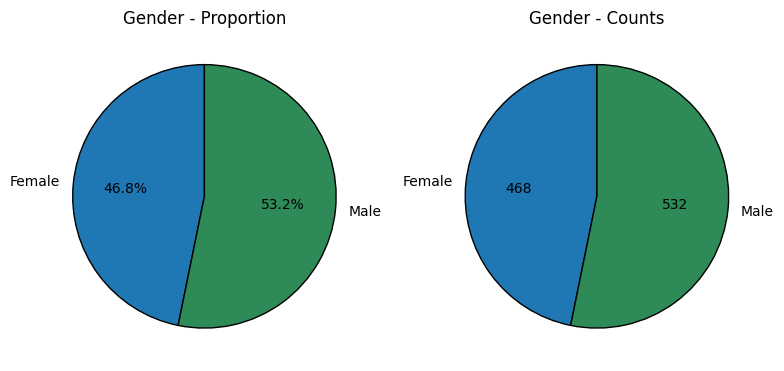

In [5]:
#Pie chart for binary variable
from visualization.explore_binary import plot_binary_distribution
plot_binary_distribution(df,['Gender'])

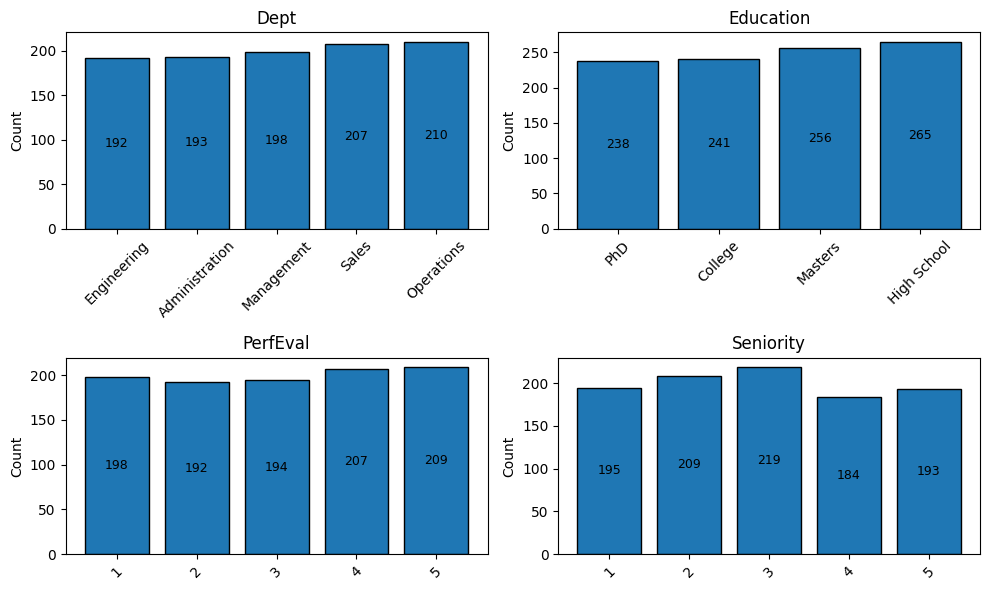

In [6]:
#Bar plots for discrete variables with few categories
discrete_cols_grid = [
  'Dept', 'Education', 'PerfEval', 'Seniority'  
]

from visualization.explore_discrete import plot_discrete_distribution_grid
plot_discrete_distribution_grid(df, discrete_cols_grid, figsize = (10,6))

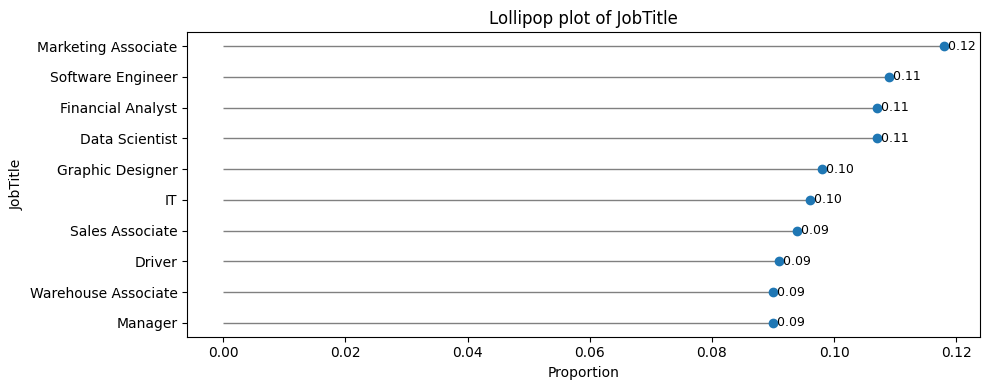

In [7]:
#Lollipop plot for JobTitle (10 categories)
from visualization.explore_discrete import plot_discrete_lollipop_distribution
plot_discrete_lollipop_distribution(df, ['JobTitle'])

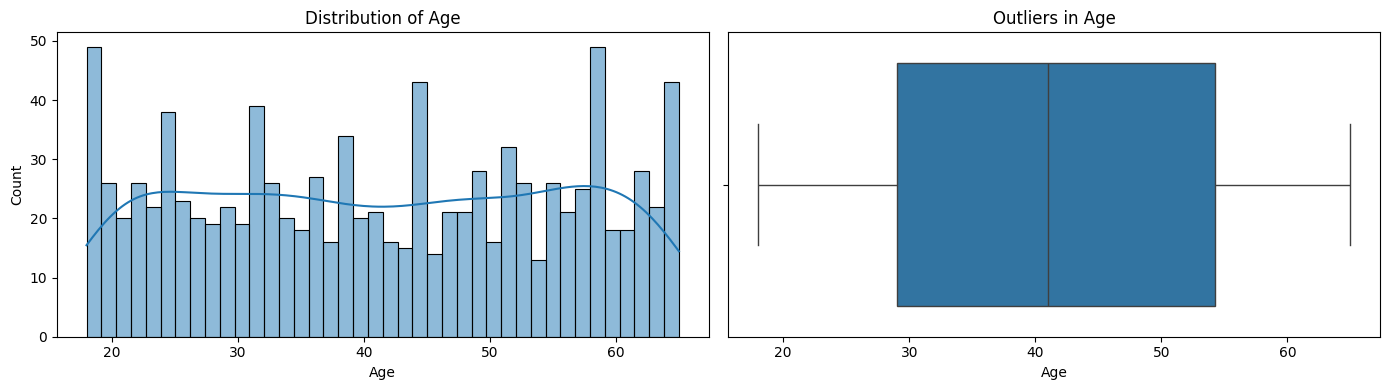

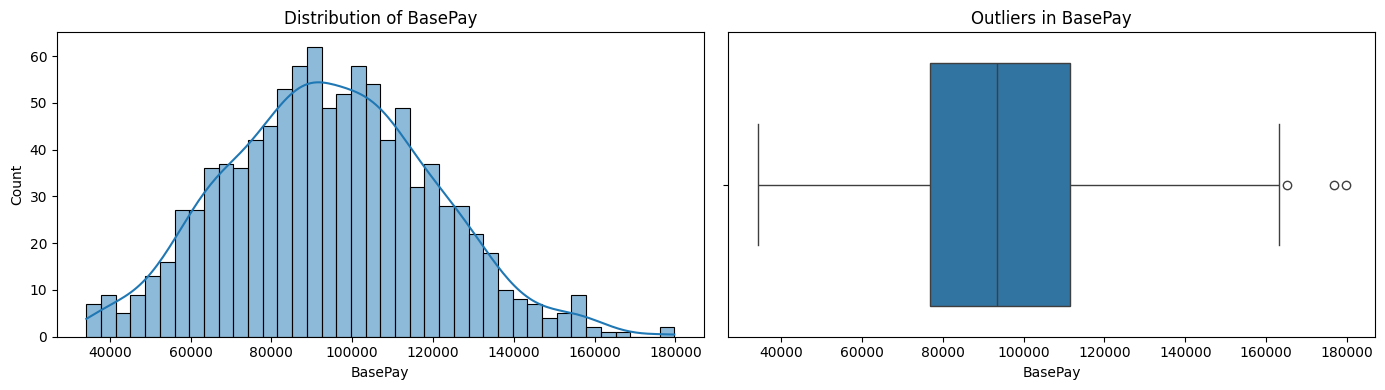

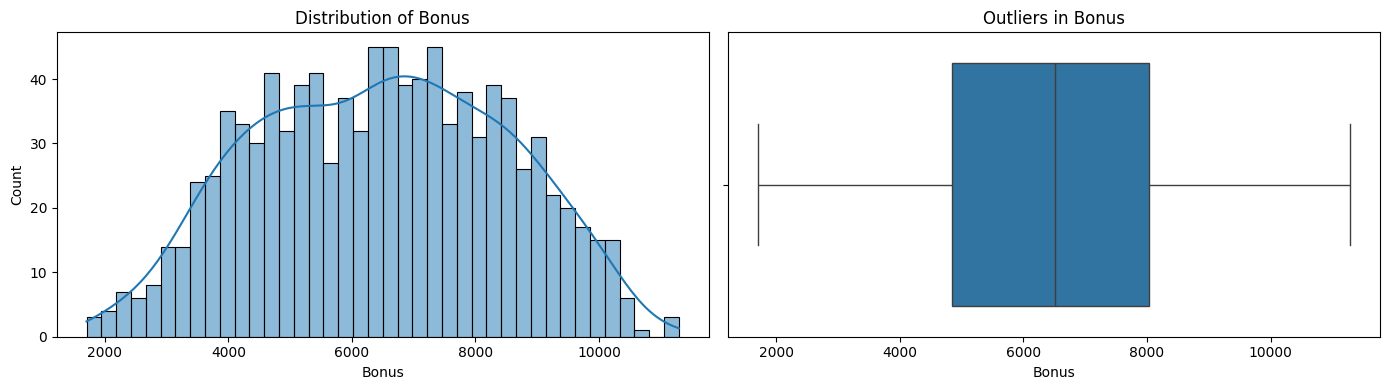

In [8]:
#Visualizing continuous variables
continuous_cols = [
    'Age', 'BasePay', 'Bonus'
]

from visualization.explore_continuous import plot_numeric_distribution
plot_numeric_distribution(df, continuous_cols)

**Key Takeaways : Univariate Analysis**

Categories across job roles, gender, education, department, performance evaluation, and seniority are relatively well balanced. Age is centered around 41 years, with a fairly symmetric distribution across the workforce. Base pay and bonus distributions seem to be fairly normal, with a few high-end outliers in base pay. Overall, the dataset provides a solid foundation for examining compensation differences across roles and demographic or performance characteristics.

## 1.3-Correlation Analysis

Before continuing with the bivariate analysis, correlations between variables will be examinated.
The normality of continuous variables (BasePay and Bonus) is assessed to determine whether
Pearson correlation is appropriate; otherwise, Spearman correlation will be used.


In [9]:
#Define colums to check
normality_check_cols = [
    'BasePay', 'Bonus'
]

from eda.check_normality import normality_check
normality_check(df, normality_check_cols)

,Column,N,Mean,Std,Shapiro-Wilk,D’Agostino K²,Anderson-Darling (5%),Kolmogorov-Smirnov
0,BasePay,1000,94472.653,25337.493272,False,True,True,True
1,Bonus,1000,6467.161,2004.377365,False,False,False,True


BasePay can be considered approximately normal due to the large sample size, as Shapiro-Wilk becomes overly sensitive for large datasets. Most other variables (including Bonus, Seniority, and PerfEval) are non-normal or ordinal/discrete. Therefore, we will use Spearman correlation to examine relationships across all variables.

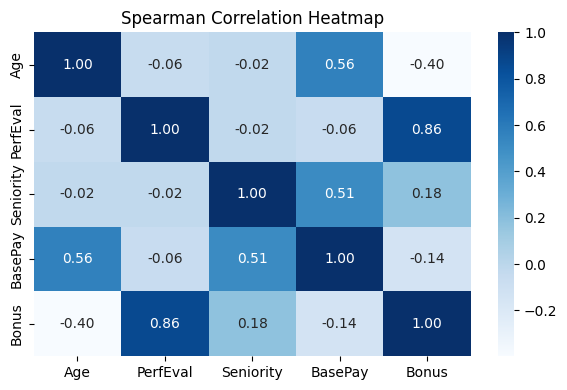

In [10]:
from visualization.explore_continuous import plot_correlation_heatmap
plot_correlation_heatmap(df, method = 'spearman', figsize = (6, 4))

Spearman correlations indicate that BasePay is moderately positively correlated with Seniority (0.51) and Age (0.56). 

Bonus is moderately negatively correlated with Age (-0.40), while showing a strong positive correlation with PerfEval (0.86). 

Other correlations are weak, suggesting limited monotonic relationships among the remaining variables.

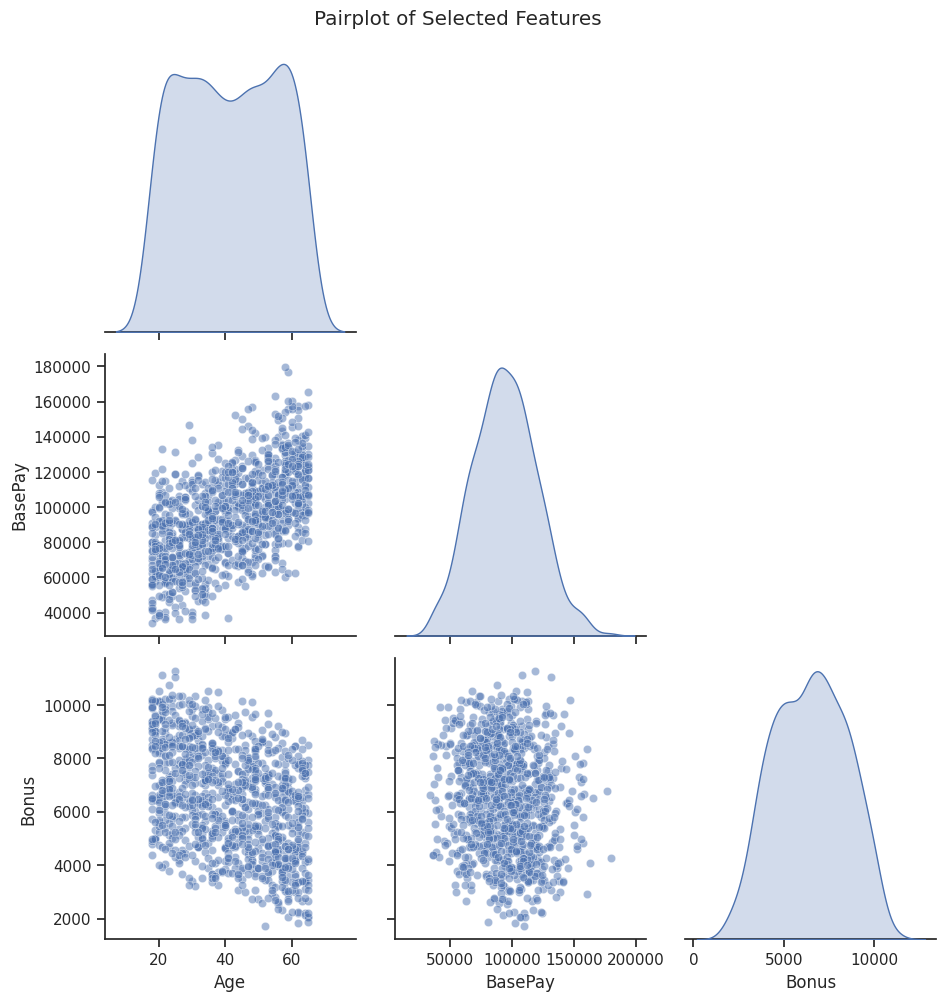

In [11]:
from visualization.explore_continuous import plot_pairplot
plot_pairplot(df, continuous_cols)

The pair plot of BasePay, Bonus, and Age highlights clear trends consistent with our Spearman correlation analysis. BasePay increases with Age, reflecting accumulation of experience or seniority, while Bonus tends to decrease slightly with Age. 

No clear relationship is observed between BasePay and Bonus. The distribution of BasePay is approximately normal, whereas Bonus shows a wider and less regular distribution, consistent with the results of our earlier normality tests.

## 1.4-Bivariate Analysis (Gender)

For the bivariate analysis, we will separate the dataset by gender and examine each feature to explore potential differences in distributions and patterns between male and female employees.

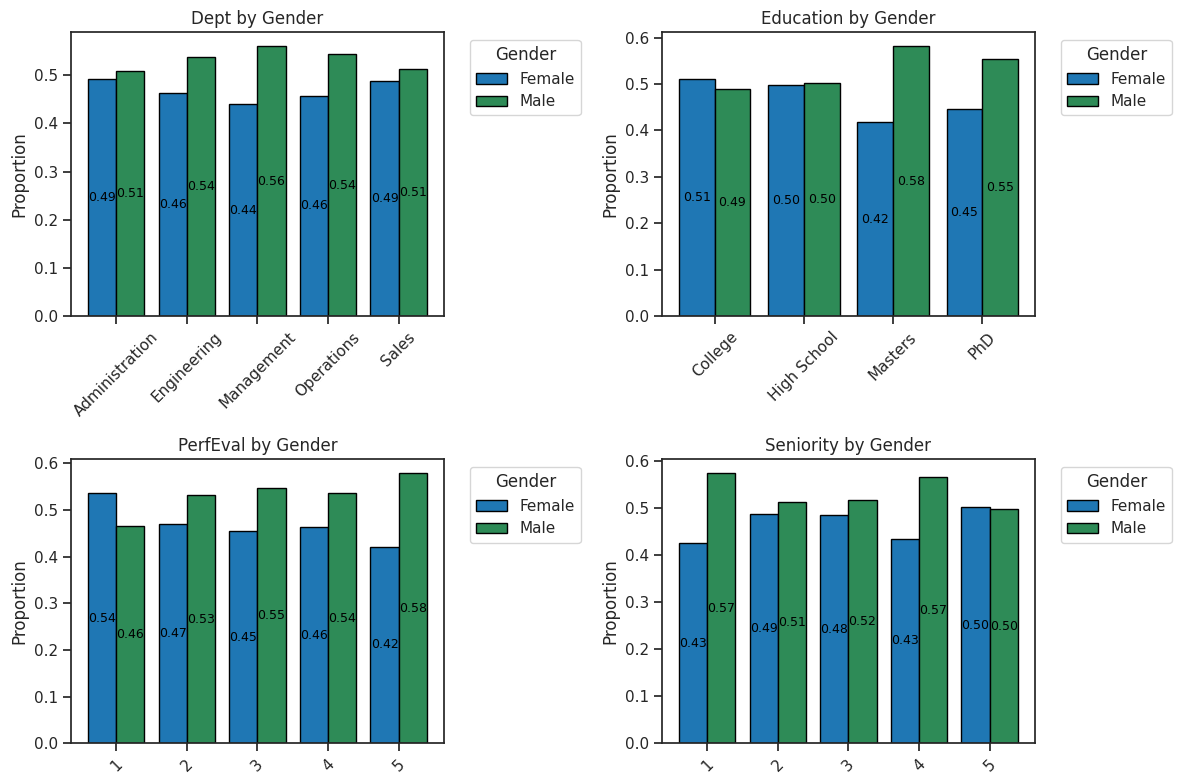

In [12]:
from visualization.explore_discrete_multivariate import plot_discrete_bivariate_grid
plot_discrete_bivariate_grid(df,discrete_cols_grid, 'Gender')

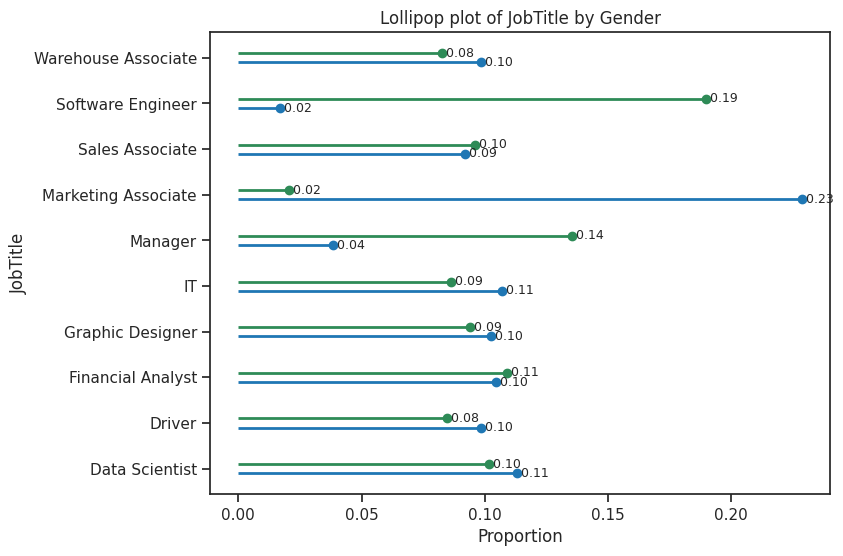

In [13]:
from visualization.explore_discrete_multivariate import plot_discrete_lollipop_bivariate
plot_discrete_lollipop_bivariate(df,'JobTitle', 'Gender', figsize = (8,6))

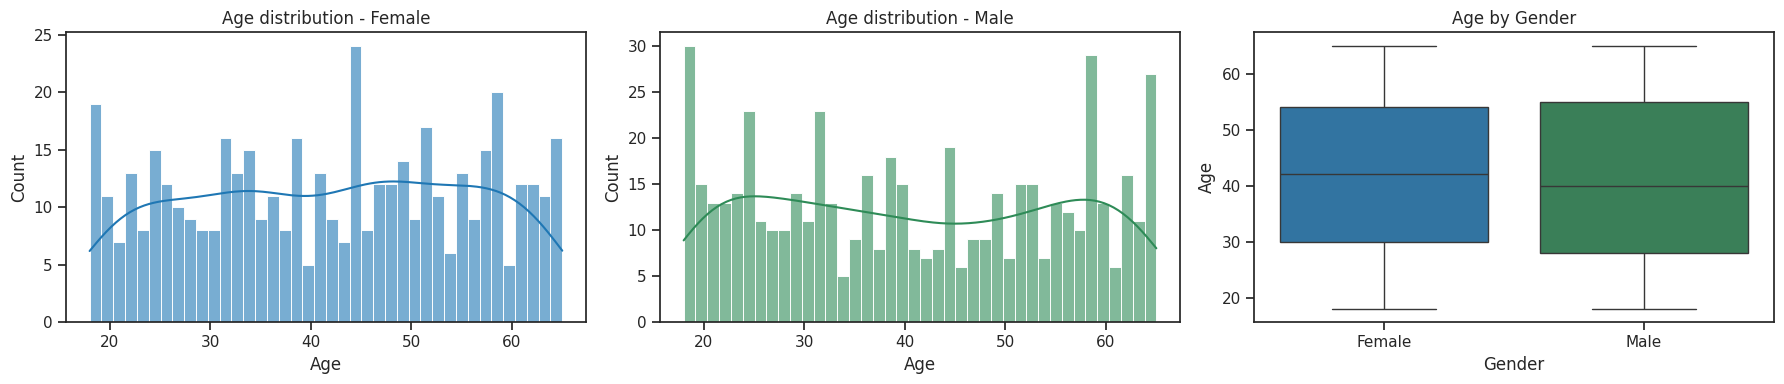

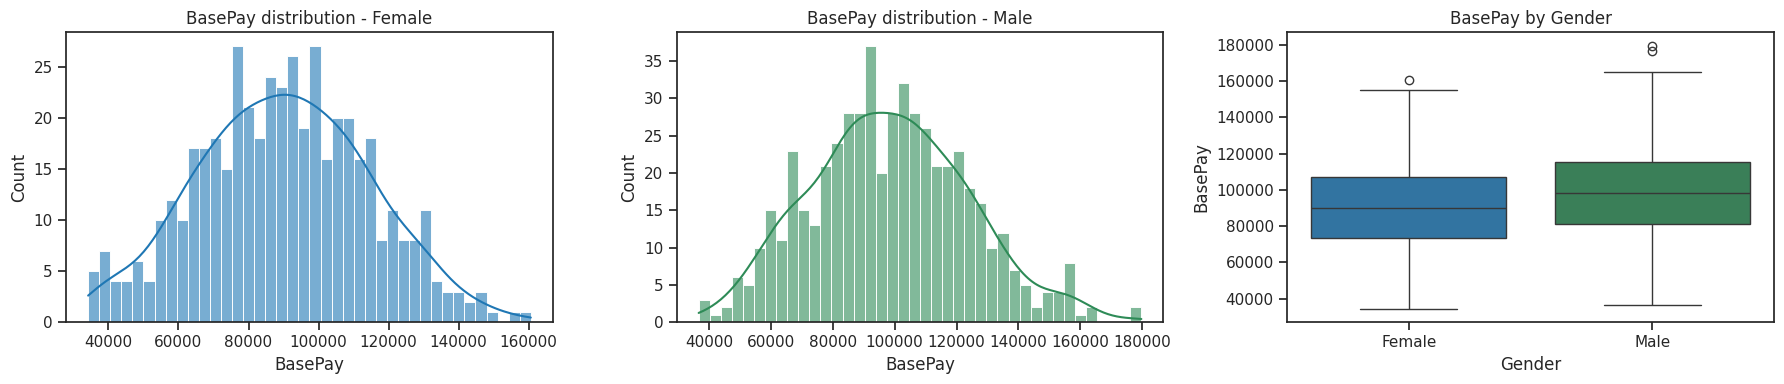

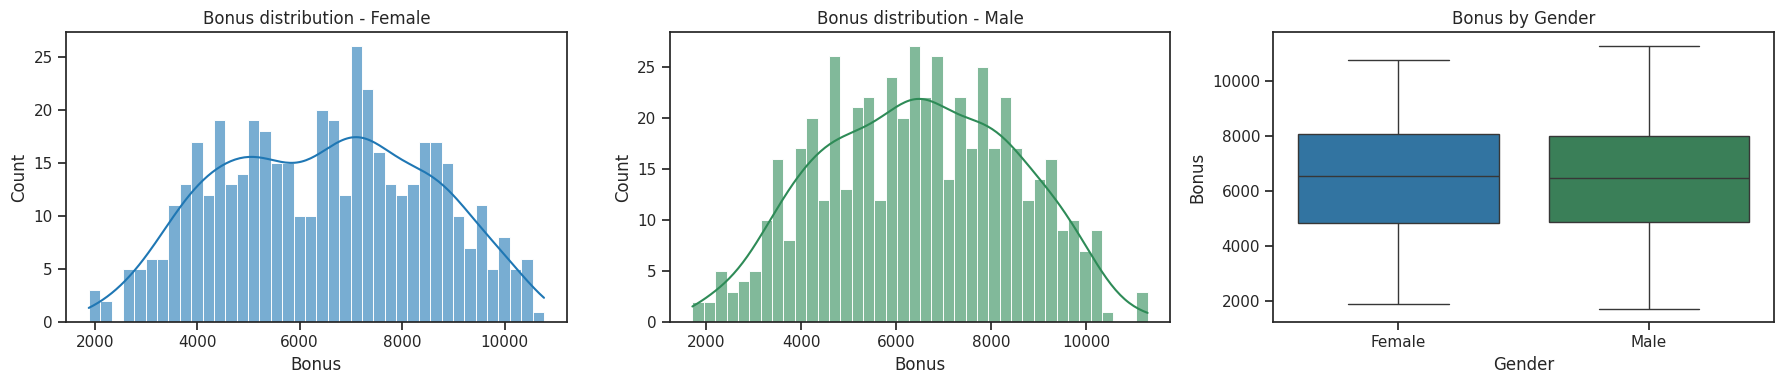

In [14]:
from visualization.explore_continuous import plot_numeric_bivariate
plot_numeric_bivariate(df, continuous_cols, 'Gender')

**Key Takeaways : Gender-Specific Bivariate Analysis**

| Variable    | Female (Mean) | Male (Mean) | Absolute Gap | Interpretation |
|------------|---------------|------------|--------------|----------------|
| BasePay    | 89,943 USD    | 98,458 USD | -8,515 USD   | Men earn more on average than women. |
| Bonus      | 6,474 USD     | 6,461 USD  | +13 USD      | Average bonus is similar across genders. |
| Age        | 41.8 years    | 41.0 years | +0.8 year    | Age distribution is similar. |
| Seniority  | 3.01          | 2.93       | +0.08        | Overall similar, except levels 1 and 4 where women are less represented. |
| PerfEval   | 2.94          | 3.13       | -0.19        | Men have a slightly higher average performance. |

**BasePay:**  
- In the histogram, men’s salaries are less concentrated toward the lower end compared to women, indicating a higher representation in higher salary ranges.  

**Bonus:**  
- Distribution between men and women is almost identical; the histogram confirms no significant differences.   

**Age:**  
- Men seem slightly overrepresented in the extreme age ranges (youngest and oldest), while women are more concentrated in the middle ages. This should be validated with further analysis.  

**Seniority:**  
- Overall distribution is similar. Women are slightly less represented in levels 1 and 4, while other levels show balanced representation.  

**PerfEval:**  
- While average scores are close, the category plots show more men in the top performance category (5) and more women in the lowest category (1), which is visually observable.

**JobTitle:**  
- Men dominate technical and managerial roles such as Software Engineer and Manager.  
- Women are overrepresented in Marketing Associate.  
- Other roles show more balanced representation.

## 1.5-Bivariate Analysis (Compensation)

In addition to the analyses presented above, BasePay and Bonus will also be examined in relation to other categorical and ordinal variables (such as JobTitle, Department, Education, Seniority, and Performance Evaluation) to further explore how compensation varies across professional contexts and to identify patterns that warrant deeper investigation.

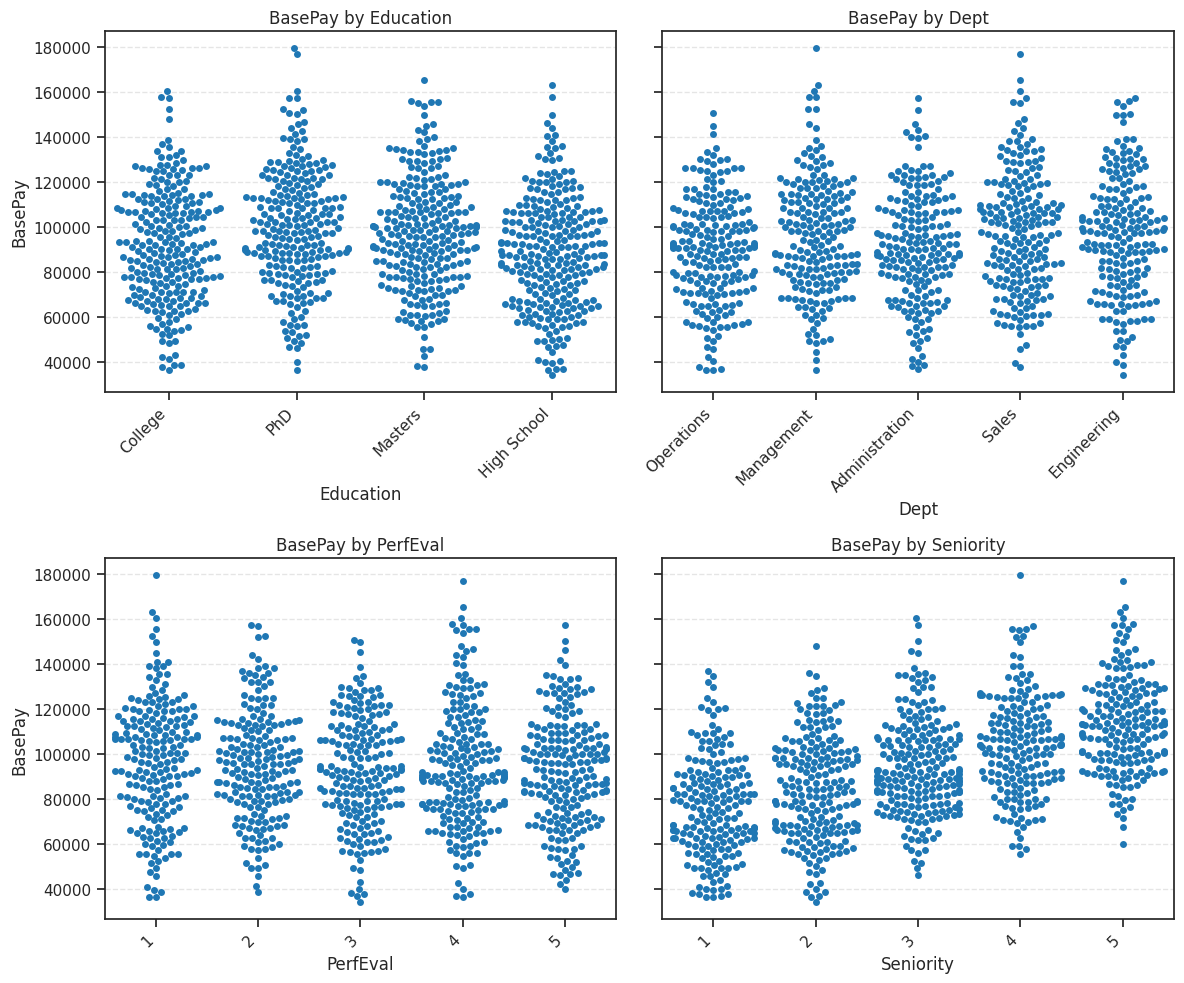

In [15]:
#Define columns to visualize
group_col = ['Education', 'Dept', 'PerfEval', 'Seniority']

from visualization.explore_continuous import plot_swarm_grid
plot_swarm_grid(df, ['BasePay'], group_col)

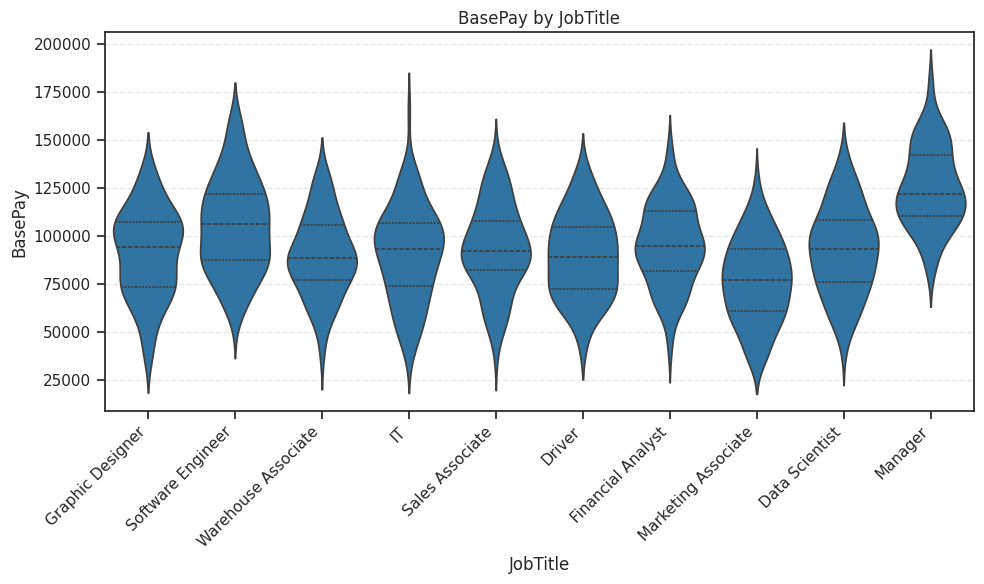

In [16]:
from visualization.explore_continuous import plot_violin_grid
plot_violin_grid(df, ['BasePay'], ['JobTitle'])

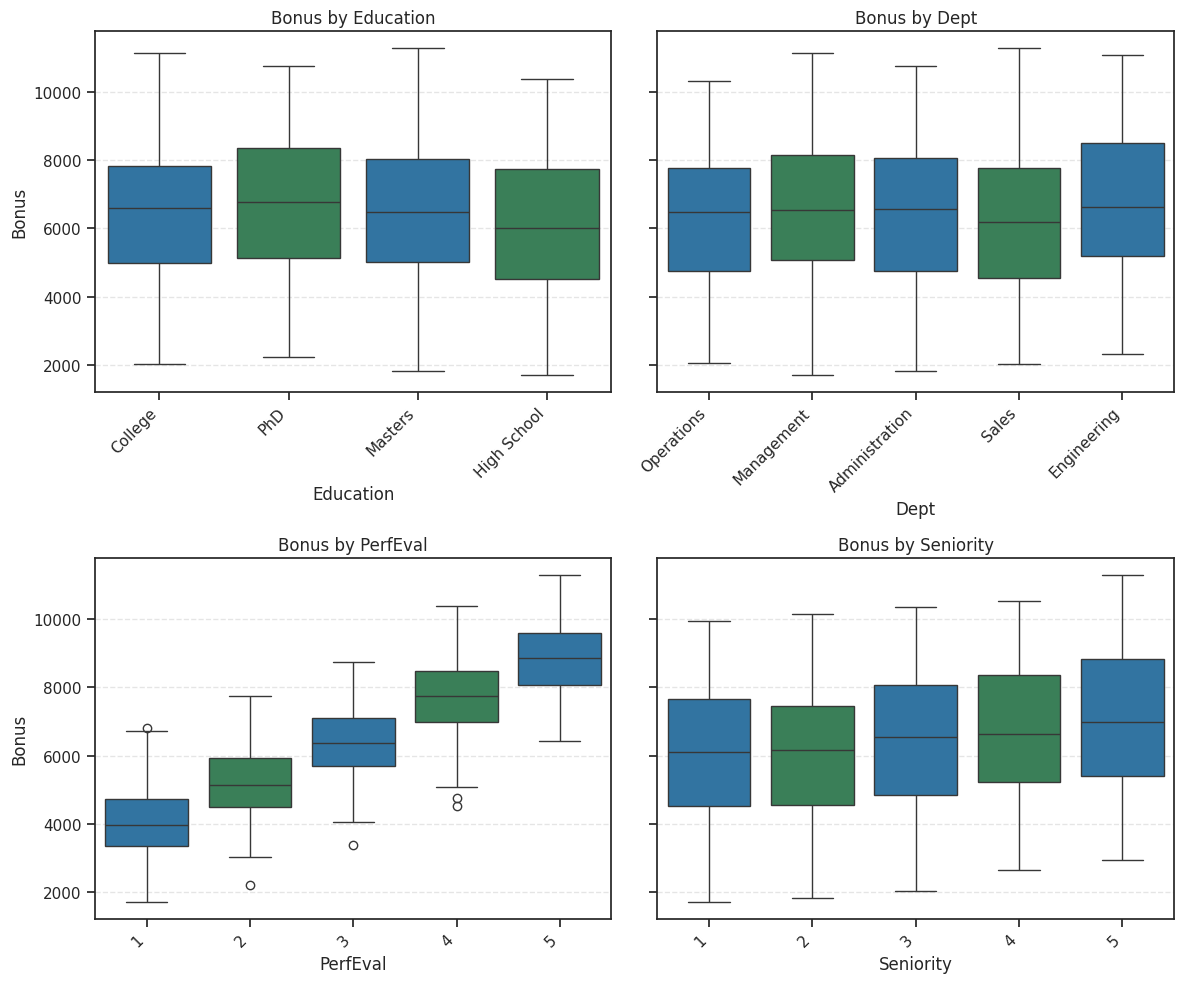

In [17]:
from visualization.explore_continuous import plot_box_grid
plot_box_grid(df, ['Bonus'], group_col = group_col)

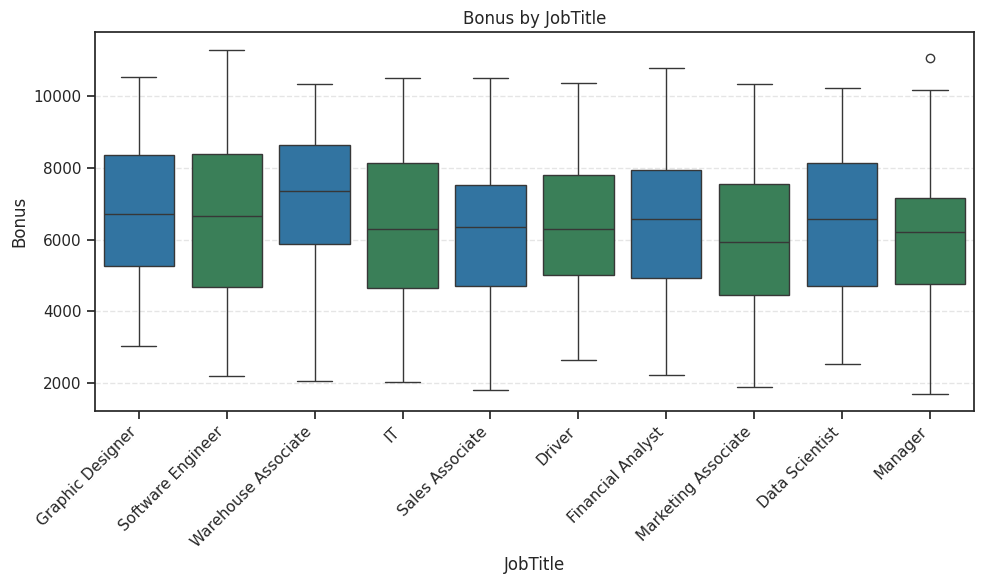

In [18]:
from visualization.explore_continuous import plot_box_grid
plot_box_grid(df, ['Bonus'], ['JobTitle'])

**Key Takeaways: Compensation-Specific Bivariate Analysis**

| Category    | Observation **(BasePay)** |
|------------|------------|
| JobTitle   | Managers and Software Engineers earn the highest salaries. Marketing Associates have the lowest salaries. Technical and managerial roles dominate higher pay. |
| Department | Sales, Engineering, and Management departments have the highest average BasePay. Operations and Administration are slightly lower. |
| Education  | Salaries generally increase with education: College < High School < Masters < PhD. PhD holders earn the most on average. |
| Seniority  | BasePay rises with seniority levels, from Level 1 to Level 5. |
| PerfEval   | Relationship less linear: Levels 1 and 4 show higher BasePay than some intermediate levels, suggesting influence from role or department. |

---

| Category    | Observation **(Bonus)** |
|------------|------------|
| JobTitle   | Warehouse Associates, Software Engineers, and Graphic Designers tend to receive higher average bonuses. Managers and Marketing Associates are lower. |
| Department | Engineering and Management offer higher bonuses; Sales slightly lower despite high BasePay; Administration and Operations moderate. |
| Education  | PhD holders receive the highest bonuses; High School the lowest. |
| Seniority  | Bonus generally increases with seniority, peaking at levels 4 and 5. |
| PerfEval   | Strong positive relationship: higher performance evaluations correspond to higher average bonuses, especially Level 5 performers. |


## 1.6-Department Overview

Before exploring general and gender-specific differences, we will start by getting a clear picture of the departments. This will help us understand the structural patterns and relationships within the organization.

### **Department: Operations**

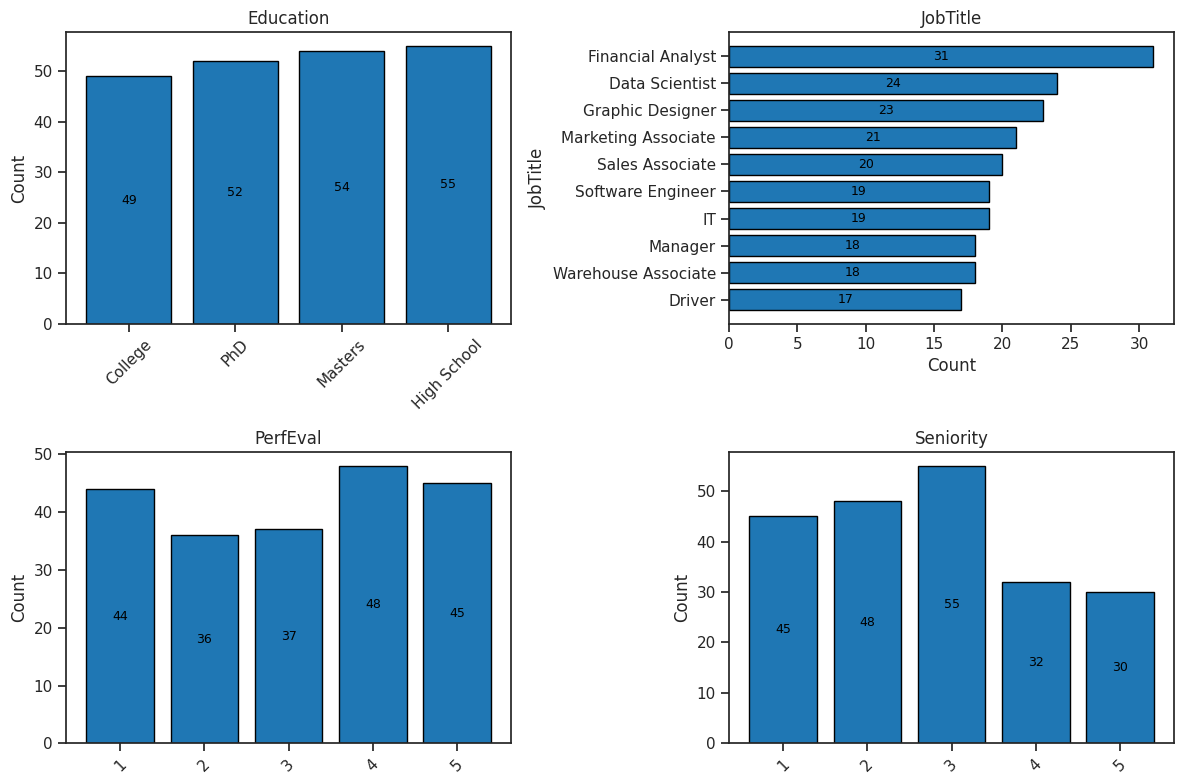

### **Department: Management**

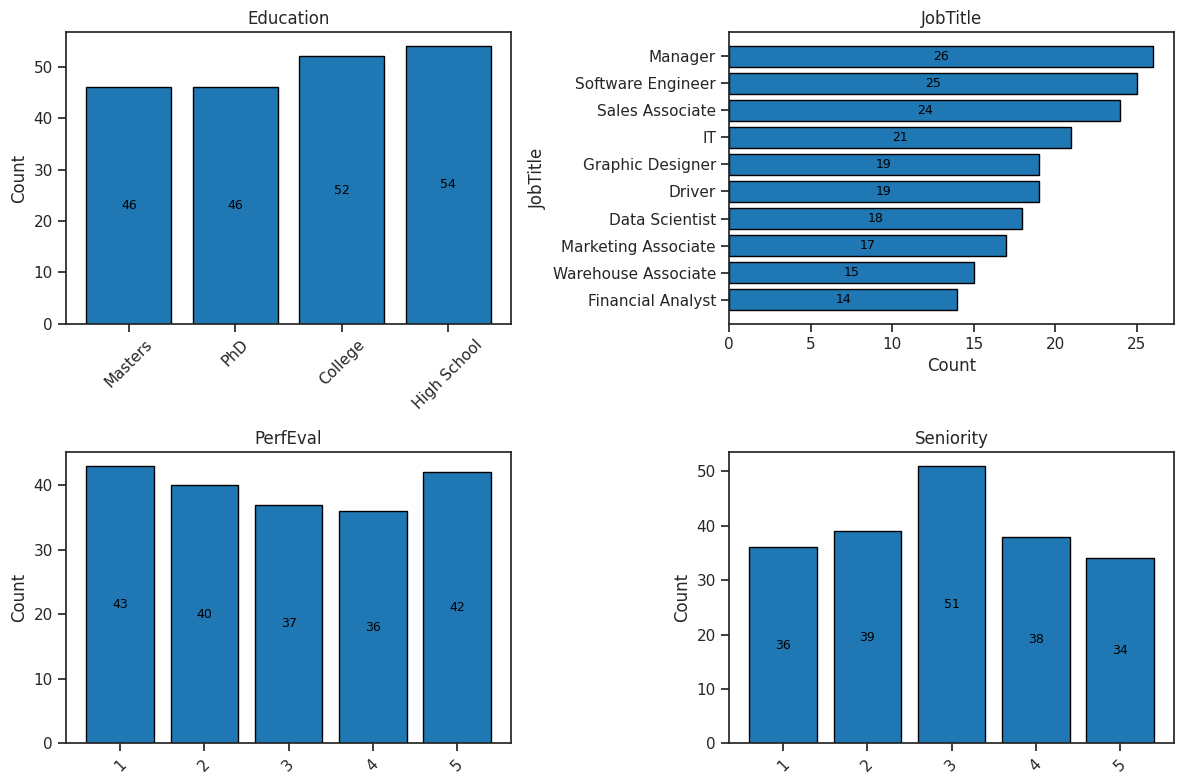

### **Department: Administration**

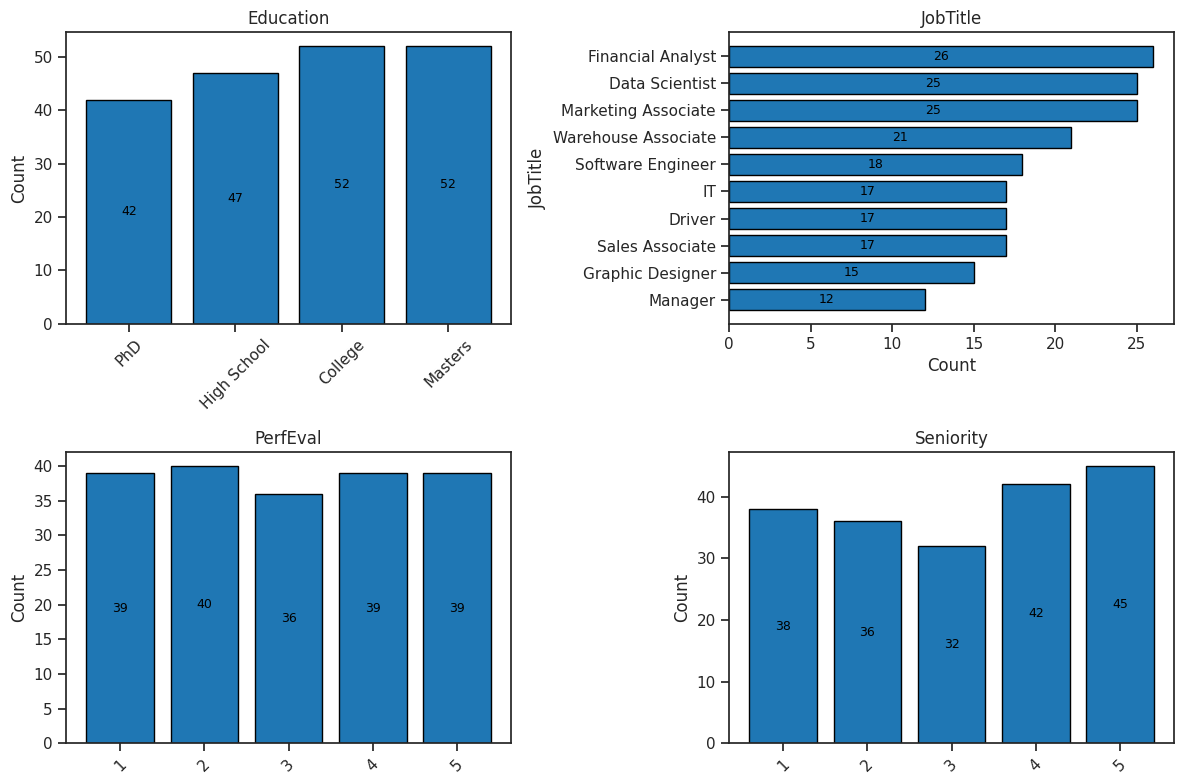

### **Department: Sales**

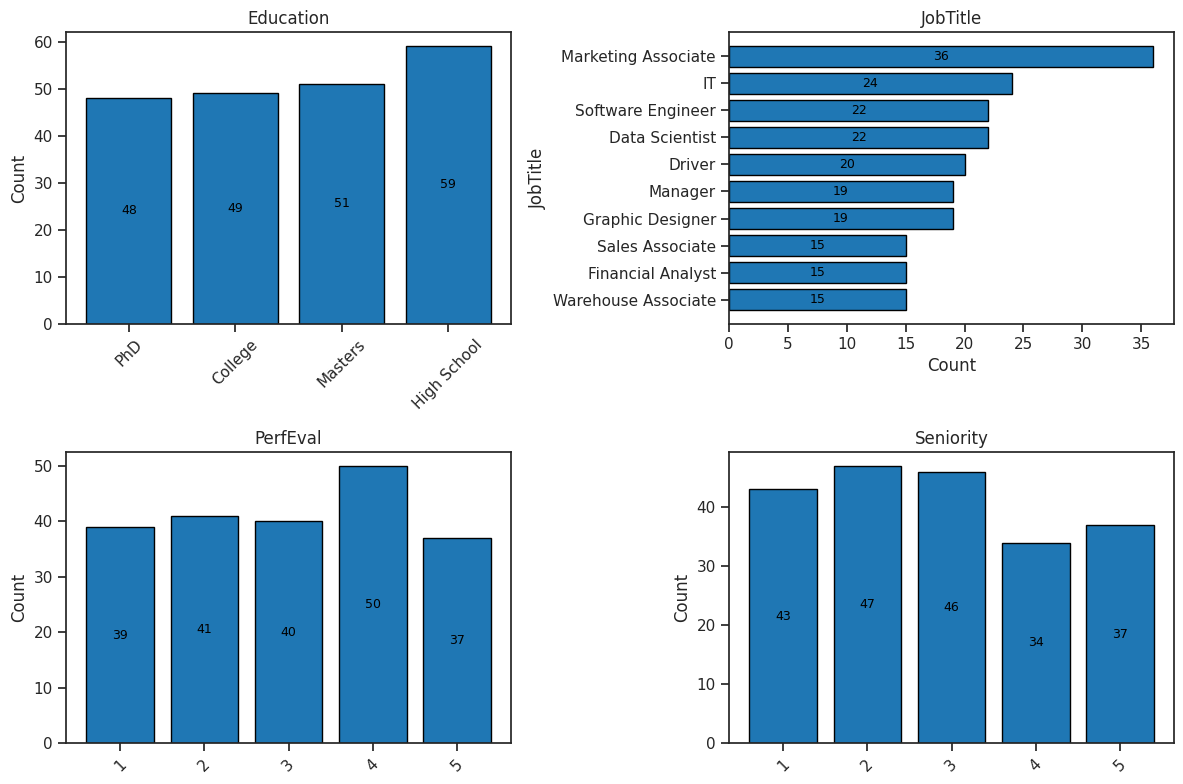

### **Department: Engineering**

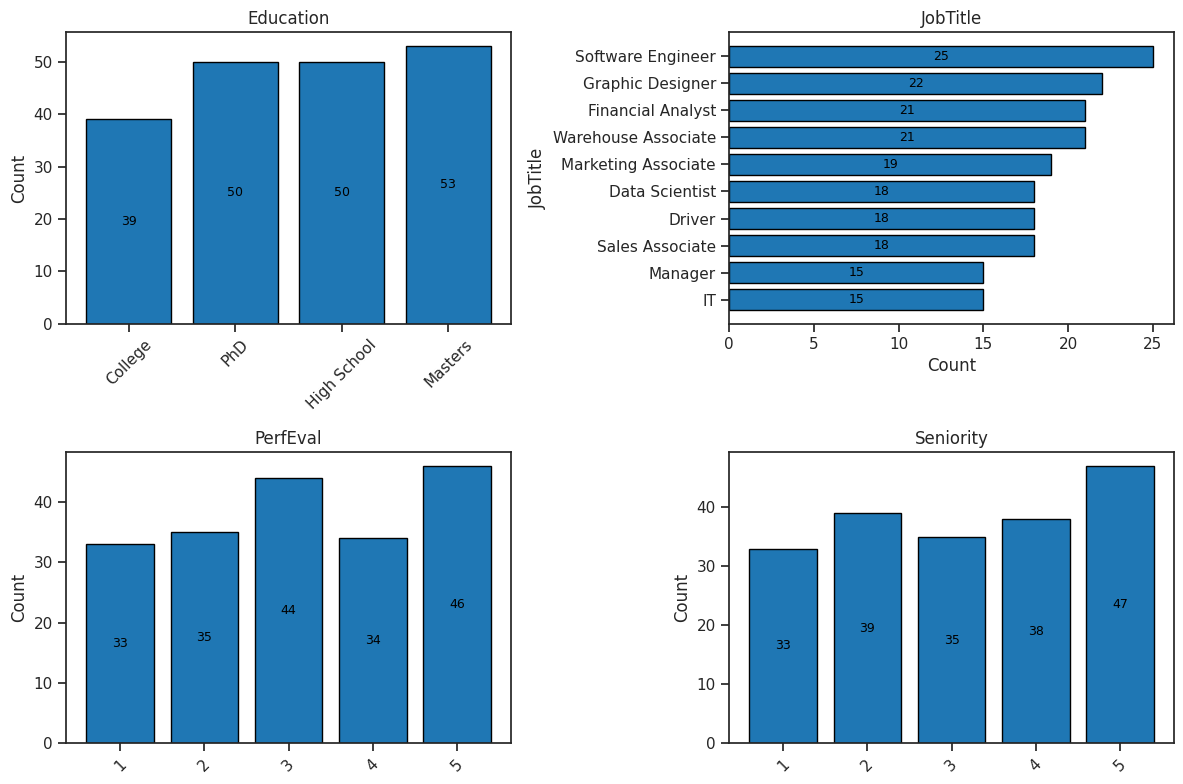

In [19]:
#List of unique departments
departments = df['Dept'].unique()

#Columns to visualize
dept_columns = ['Education', 'JobTitle', 'PerfEval', 'Seniority']

#Import function and loop over each department
from visualization.explore_discrete import plot_discrete_distribution_grid

for dept in departments:
    from IPython.display import display, Markdown
    display(Markdown(f"### **Department: {dept}**"))
    df_dept = df[df['Dept'] == dept]
    plot_discrete_distribution_grid(df_dept, dept_columns)

In [20]:
#The goal here is to provide a concise summary of each department's workforce by calculating the average
#age of employees, median base pay, and median bonus.

#Group by department
dept_summary = (
    df
    .groupby('Dept')  
    .agg(
        avg_age=('Age', 'mean'),          
        median_basepay=('BasePay', 'median'),  
        median_bonus=('Bonus', 'median')       
    )
    .reset_index()
)

#Round values for readability
dept_summary['avg_age'] = dept_summary['avg_age'].round(1)
dept_summary['median_basepay'] = dept_summary['median_basepay'].round(0)
dept_summary['median_bonus'] = dept_summary['median_bonus'].round(0)

#Display the table
dept_summary

,Dept,avg_age,median_basepay,median_bonus
0,Administration,40.8,90612.0,6581.0
1,Engineering,40.6,97646.0,6630.0
2,Management,41.2,96520.0,6556.0
3,Operations,41.4,91144.0,6492.0
4,Sales,42.8,97311.0,6179.0


**Department Overview - Summary**

| Department      | Education                            | PerfEval                         | Seniority                          | JobTitle Highlights                              | Avg Age | Median BasePay | Median Bonus |
|-----------------|--------------------------------------|----------------------------------|------------------------------------|-------------------------------------------------|---------|----------------|--------------|
| Operations      | Well balanced across all levels      | Slightly higher at 4–5           | Mostly levels 2–3                  | Financial Analyst, Data Scientist, Graphic Designer | 41.4    | 91,144         | 6,492        |
| Management      | College & High School slightly higher| Fairly uniform (1–5)             | Concentration at level 3           | Manager, Software Engineer, Sales Associate     | 41.2    | 96,520         | 6,556        |
| Administration  | College & Masters most common        | Very evenly distributed          | More senior levels (4–5)           | Financial Analyst, Data Scientist, Marketing Associate | 40.8    | 90,612         | 6,581        |
| Sales           | High School slightly dominant        | PerfEval 4 most frequent         | Levels 2–3 dominate, fewer level 4| Marketing Associate, IT, Software Engineer      | 42.8    | 97,311         | 6,179        |
| Engineering     | Masters & PhD slightly dominant      | Higher at 3 and 5                | More senior (level 5)              | Software Engineer, Graphic Designer, Financial Analyst | 40.6    | 97,646         | 6,630        |


## 1.7-Department Overview (Gender-Specific) 

### **Department: Operations**

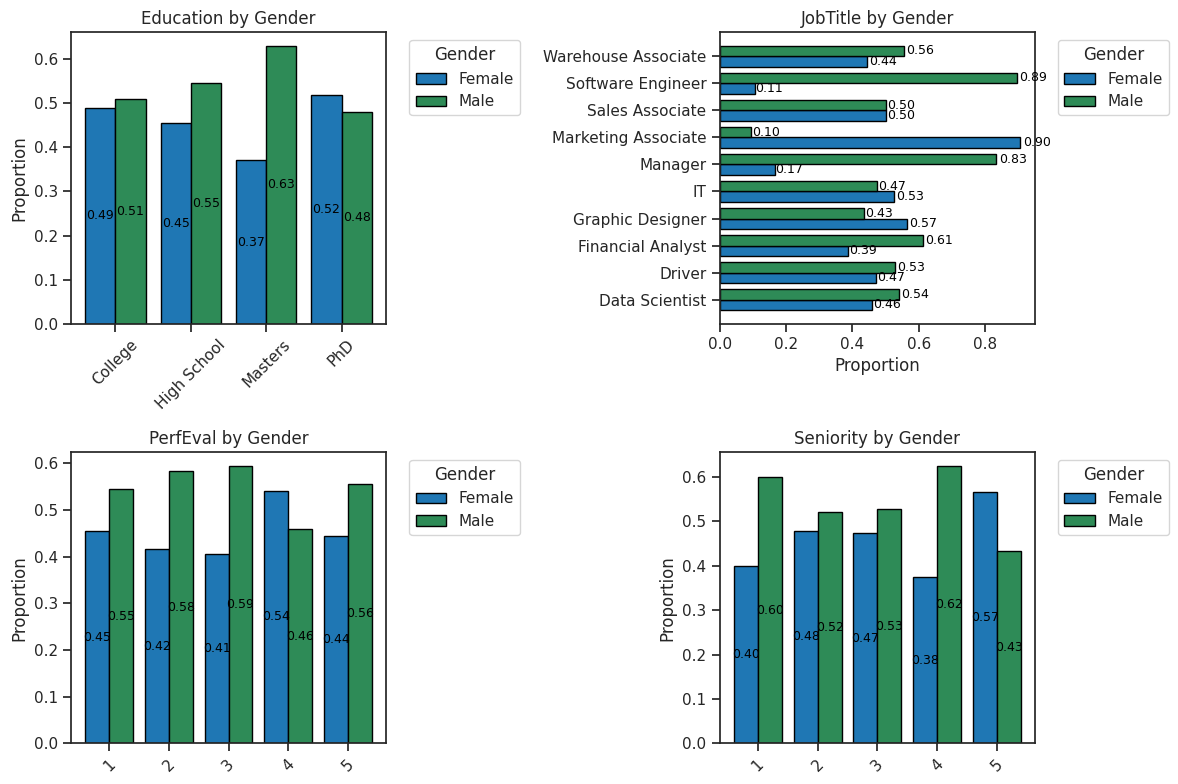

### **Department: Management**

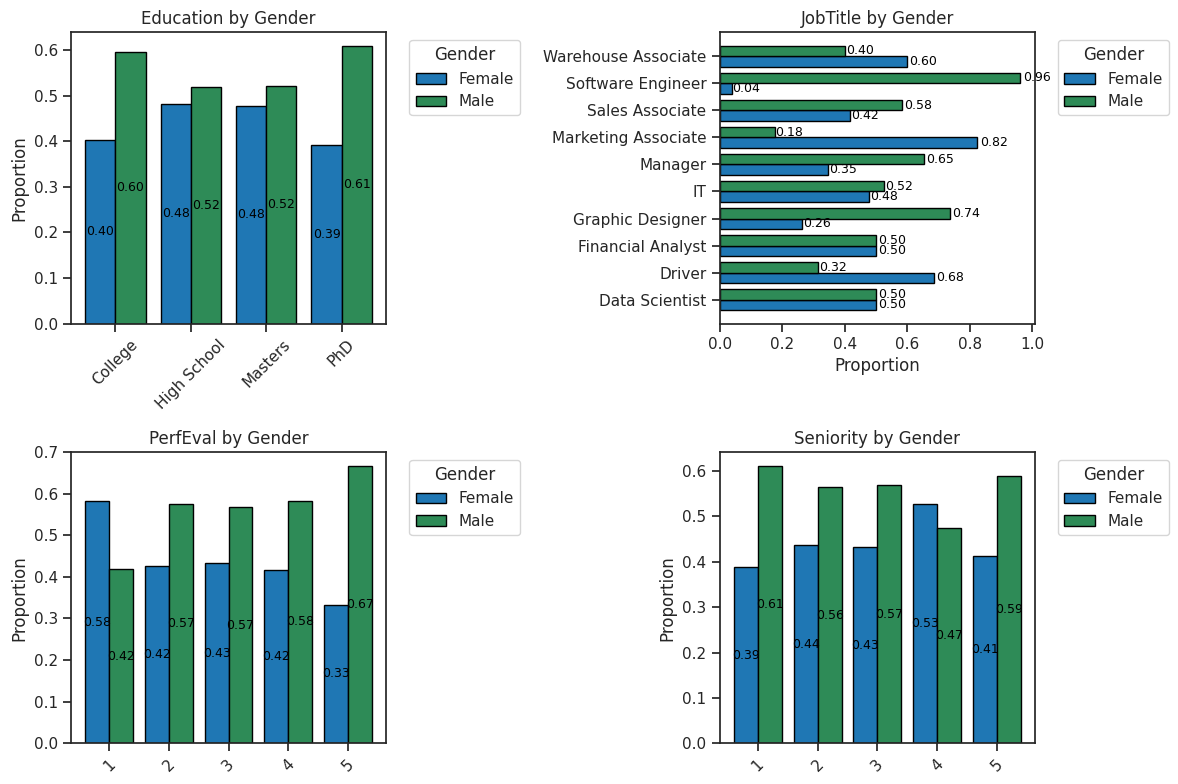

### **Department: Administration**

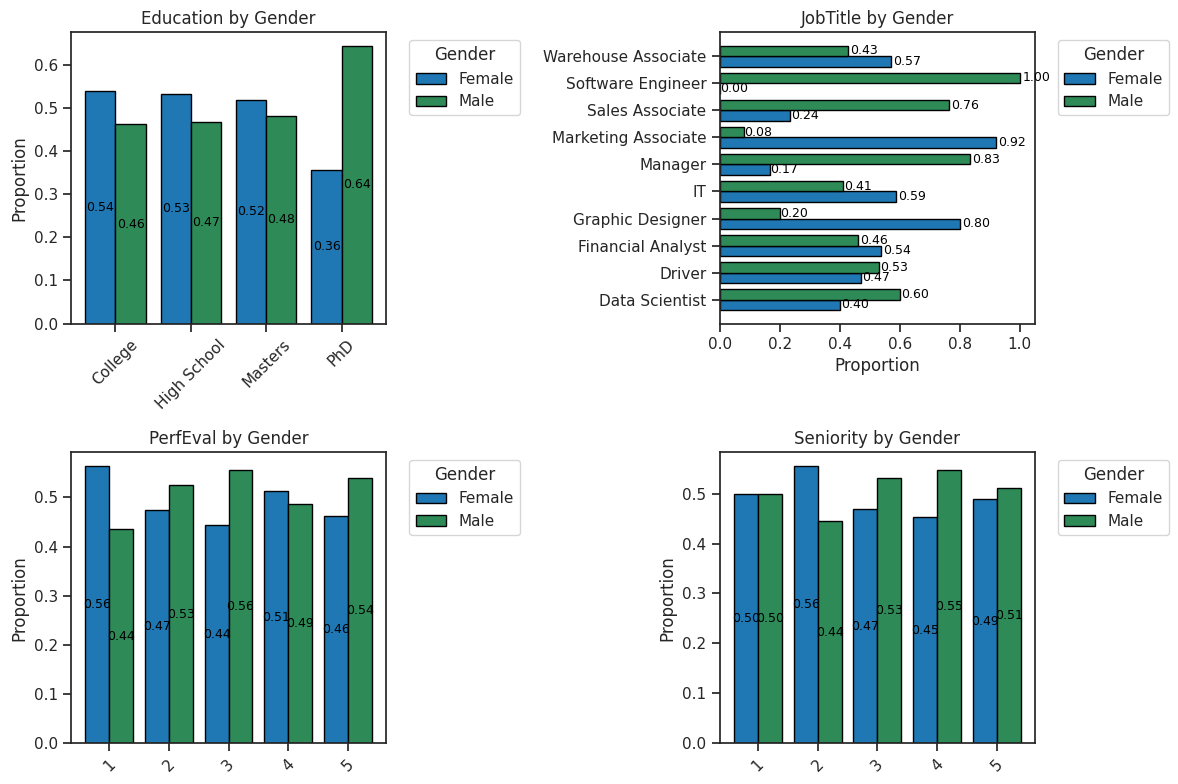

### **Department: Sales**

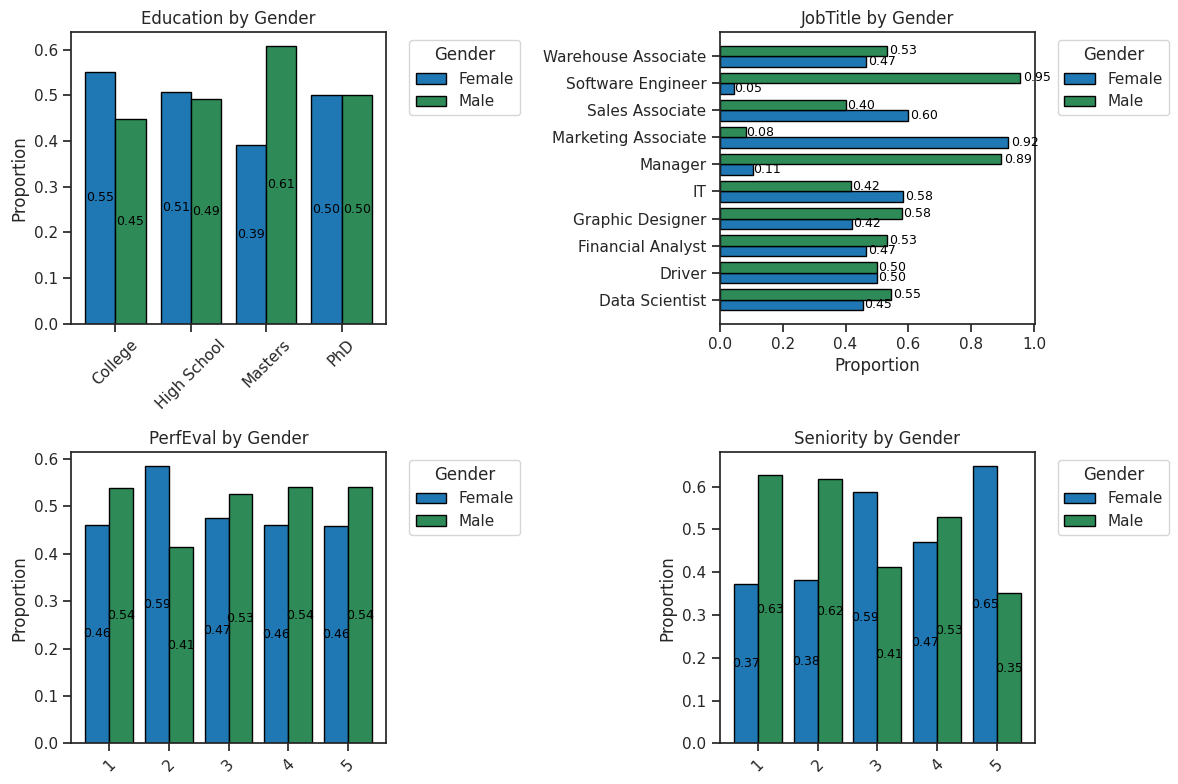

### **Department: Engineering**

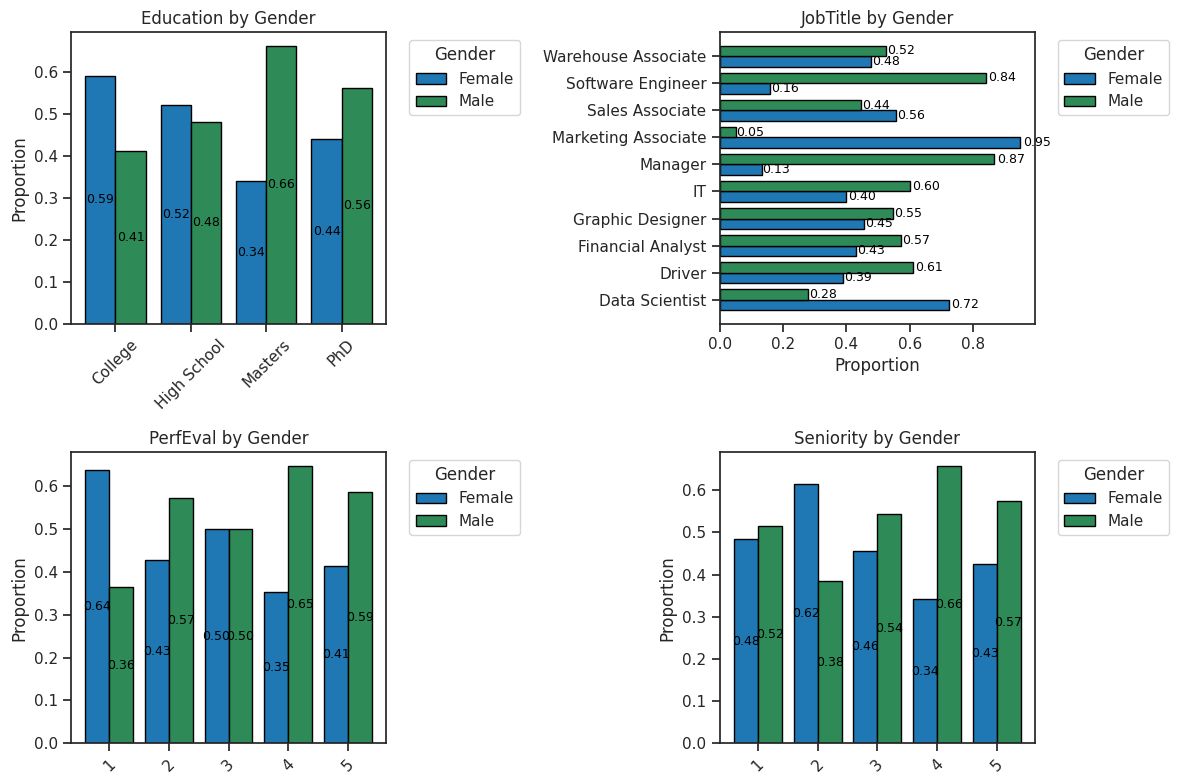

In [21]:
#Import function and loop over each department
from visualization.explore_discrete_multivariate import plot_discrete_bivariate_grid

for dept in departments:
    from IPython.display import display, Markdown
    display(Markdown(f"### **Department: {dept}**"))
    df_dept = df[df['Dept'] == dept]
    plot_discrete_bivariate_grid(df_dept, dept_columns, 'Gender')

In [22]:
# The goal here is to provide a concise summary of each department's workforce by calculating the average
#age of employees, median base pay, and median bonus, separately for each gender.

#Group by department and gender
dept_gender_summary = (
    df
    .groupby(['Dept', 'Gender'])  
    .agg(
        avg_age=('Age', 'mean'),          
        median_basepay=('BasePay', 'median'),  
        median_bonus=('Bonus', 'median')       
    )
    .reset_index()
)

#Round values for readability
dept_gender_summary['avg_age'] = dept_gender_summary['avg_age'].round(1)
dept_gender_summary['median_basepay'] = dept_gender_summary['median_basepay'].round(0)
dept_gender_summary['median_bonus'] = dept_gender_summary['median_bonus'].round(0)

#Display the table
dept_gender_summary

,Dept,Gender,avg_age,median_basepay,median_bonus
0,Administration,Female,41.3,87608.0,6386.0
1,Administration,Male,40.4,93561.0,6692.0
2,Engineering,Female,42.6,91300.0,6615.0
3,Engineering,Male,38.8,102261.0,6692.0
4,Management,Female,41.5,90426.0,6496.0
5,Management,Male,41.0,98499.0,6739.0
6,Operations,Female,41.1,87416.0,6996.0
7,Operations,Male,41.7,92223.0,6350.0
8,Sales,Female,42.6,93805.0,6432.0
9,Sales,Male,42.9,104134.0,6030.0


**Gender-Specific Department Overview - Summary**

| Department      | Education Highlights (F/M)                 | PerfEval Highlights (F/M)             | Seniority Highlights (F/M)             | JobTitle Highlights (F/M)                                   | Avg Age (F/M) | Median BasePay (F/M) | Median Bonus (F/M) |
|-----------------|-------------------------------------------|--------------------------------------|---------------------------------------|------------------------------------------------------------|---------------|--------------------|------------------|
| Operations      | College balanced (24/25), Masters lower for F (20) than M (34), PhD balanced | Slightly higher males at 5 (25M vs 20F) | Levels 3 male dominant (29M vs 26F), Level 4 underrepresented F | Manager and Software Engineer mainly males, Marketing Associate mainly females | 41.1 / 41.7  | 87,416 / 92,223    | 6,996 / 6,350    |
| Management      | College & PhD males higher than females, High School & Masters roughly balanced | Level 5 male dominant (28M vs 14F) | Level 3 male dominant (29M vs 22F) | Software Engineer & Manager mainly males, Marketing Associate mainly females | 41.5 / 41.0  | 90,426 / 98,499    | 6,496 / 6,739    |
| Administration  | PhD males higher than females, College & Masters balanced | Level 5 slightly higher males | Levels 4–5 slightly male dominant | Software Engineer mainly males, Marketing Associate mainly females | 41.3 / 40.4  | 87,608 / 93,561    | 6,386 / 6,692    |
| Sales           | High School F slightly dominant (30F vs 29M) | Level 4 slightly higher males | Level 1–3 males slightly dominant, Level 5 females higher | Software Engineer & Manager mainly males, Marketing Associate mainly females | 42.6 / 42.9  | 93,805 / 104,134   | 6,432 / 6,030    |
| Engineering     | Masters & PhD males dominant (35M & 28F) | Level 5 males higher (27M vs 19F) | Level 4–5 males dominant | Software Engineer & Financial Analyst mainly males, Marketing Associate mainly females | 42.6 / 38.8  | 91,300 / 102,261   | 6,615 / 6,692    |


The **gender drill-down** highlights several nuances:

**Operations**: Senior roles and managers are mostly male, while Marketing Associates are predominantly female. Men are slightly older on average (41.7 vs 41.1 years) and earn higher median base pay (92,223 vs 87,416 USD) but slightly lower median bonus (6,350 vs 6,996 USD). Men are also more represented among Masters and PhD holders.

**Management**: Technical and leadership roles (Software Engineer, Manager) are heavily male, whereas Marketing Associates remain female. Men are slightly younger on average (41.0 vs 41.5 years) but earn substantially higher median base pay (98,499 vs 90,426 USD) and higher median bonus (6,739 vs 6,496 USD).

**Administration**: Distribution is generally balanced, though PhD holders and senior roles lean male. Men are slightly younger (40.4 vs 41.3 years), earn higher median base pay (93,561 vs 87,608 USD) and bonus (6,692 vs 6,386 USD). Marketing Associates remain female.

**Sales**: Leadership and technical roles are mostly male, while Marketing Associates are highly female. Men are slightly older (42.9 vs 42.6 years), with higher median base pay (104,134 vs 93,805 USD) but lower median bonus (6,030 vs 6,432 USD).

**Engineering**: Technical and senior roles are predominantly male. Men are younger (38.8 vs 42.6 years) but earn significantly higher median base pay (102,261 vs 91,300 USD) with slightly higher median bonus (6,692 vs 6,615 USD).

This drill-down shows that gender disparities are evident in seniority, education, and compensation, with men generally occupying higher-paid positions and women more concentrated in certain roles, patterns that are not obvious in a department-level summary alone.


## 1.8-Multivariate Analysis

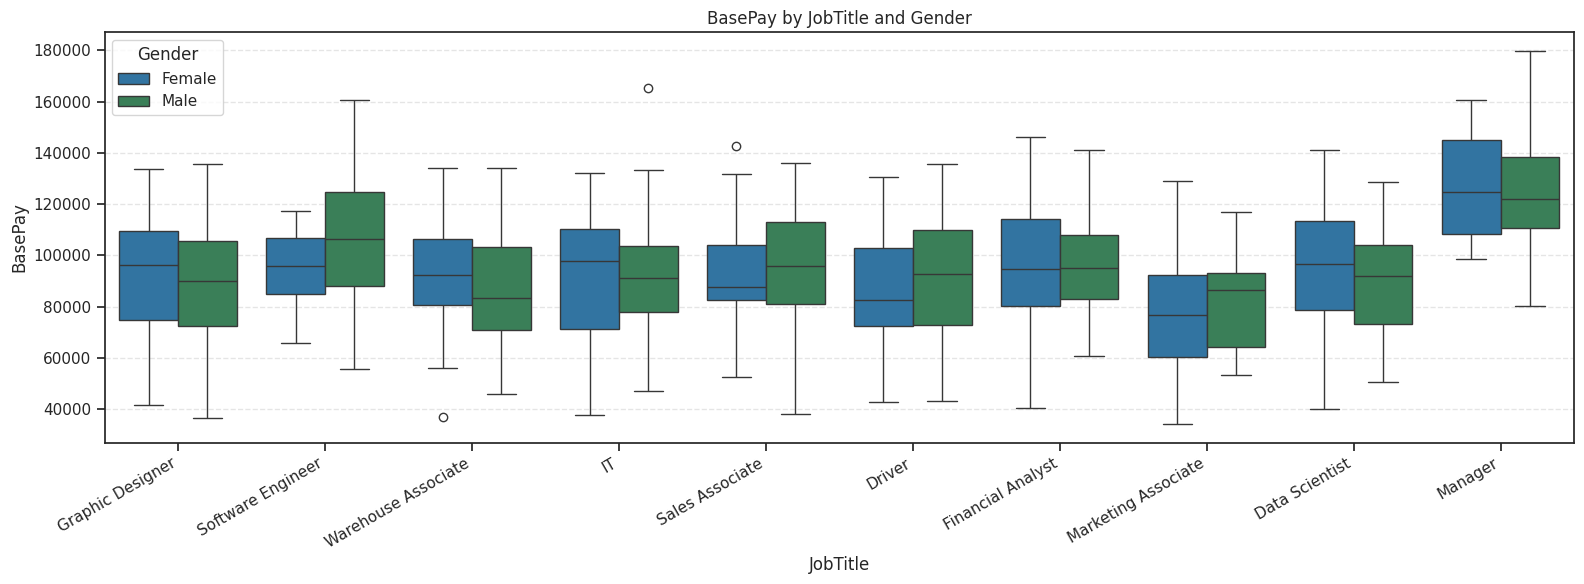

In [23]:
#This visualization explores the distribution of base salary across job titles, with a gender-based split.
from visualization.explore_continuous import plot_box_plot
plot_box_plot(df, ['BasePay'], 'JobTitle', 'Gender')

Median base pay is generally similar between males and females within most job titles, with some roles favoring females (e.g., Financial Analyst, Data Scientist) and others favoring males (e.g., Driver, Software Engineer). 

Some roles, like Manager and Software Engineer, show greater salary dispersion among males, while female salaries are more concentrated, partly due to smaller sample sizes. 

Differences often reflect variability and distribution rather than consistent gaps, and comparisons should be interpreted cautiously in roles with unbalanced gender representation.

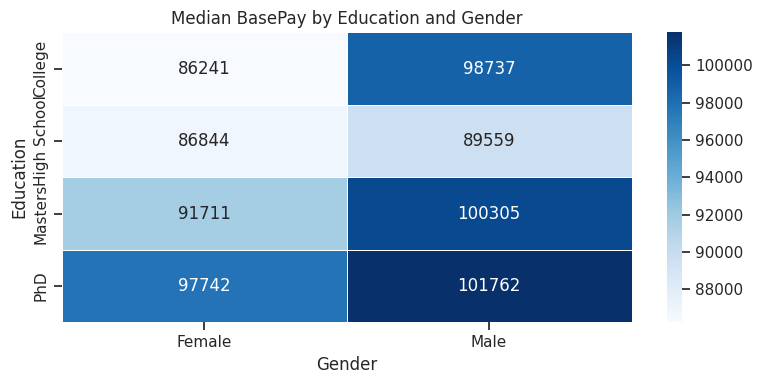

In [24]:
from visualization.explore_continuous import plot_heatmap_grid
plot_heatmap_grid(df, 'BasePay', 'Education', 'Gender', aggfunc = 'median', figsize = (8,4) )

Median base pay increases consistently with education level for both genders, confirming the strong structural role of educational attainment in fixed compensation. Within each education category, males exhibit higher median base pay than females, with the largest gap observed at the college level. Although the gap narrows at higher education levels, it remains present even among PhD holders, indicating that higher education alone does not eliminate gender-based differences in base salary.

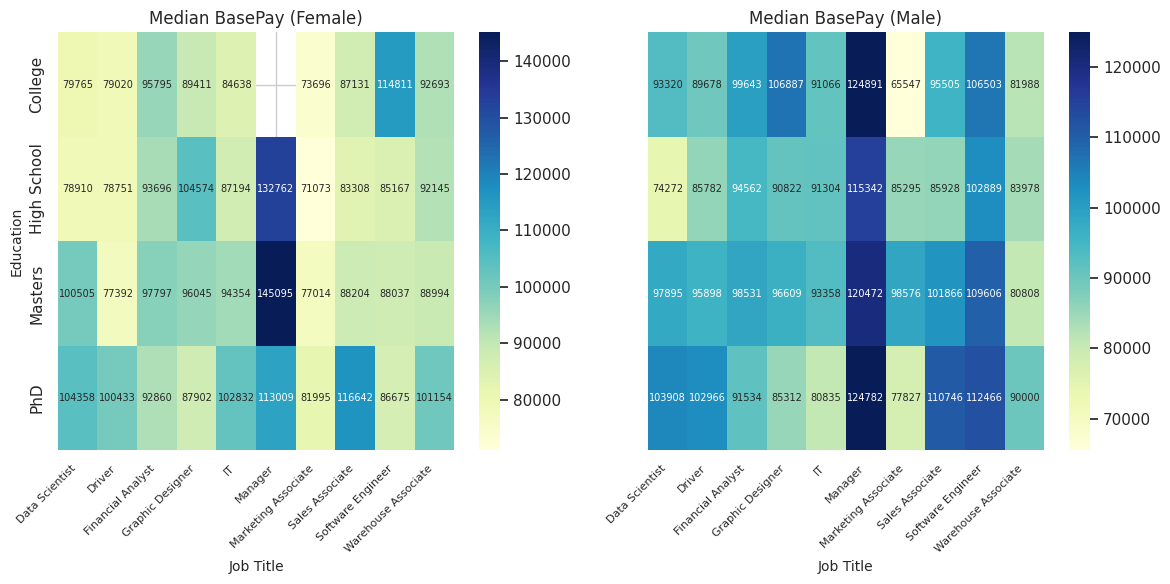

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

#Get unique genders
genders = df['Gender'].unique()
n_genders = len(genders)

#Create subplots side by side
fig, axes = plt.subplots(1, n_genders, figsize = (6*n_genders, 6), sharey = True)

#Loop over genders to create one heatmap per gender
for i, gender in enumerate(genders):
    subset = df[df['Gender'] == gender]
    
    #Create a pivot table: index = Education, columns = JobTitle, values = median BasePay
    pivot = subset.pivot_table(
        index='Education',
        columns='JobTitle',
        values='BasePay',
        aggfunc='median'
    )
    
    #Plot heatmap with smaller annotations for fitting
    sns.heatmap(
        pivot, 
        annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[i],
        annot_kws={"size": 7}  #Reduce font size of annotations
    )
    
    #Set title for each heatmap
    axes[i].set_title(f"Median BasePay ({gender})", fontsize=12)
    axes[i].set_xlabel("Job Title", fontsize=10)
    axes[i].set_ylabel("Education" if i==0 else "", fontsize=10)

#Rotate x-axis labels for readability
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

#Adjust layout for readability
plt.tight_layout()
plt.show()

The heatmaps show the median BasePay across Job Titles, Education levels, and Gender. Overall, salary differences between males and females vary depending on the job and education. For example, among College graduates, males generally earn more in roles like Data Scientist (+13,555), Driver (+10,658), and Graphic Designer (+17,476), whereas females have higher median pay in roles such as Marketing Associate (-8,150) and Software Engineer (-8,308).

At the High School level, males dominate in Software Engineer (+17,722) and Driver (+7,031), while females earn more in Graphic Designer (-13,752) and Marketing Associate (-14,222). Among Masters and PhD holders, some roles show a larger male advantage (e.g., Software Engineer +21,569 for Masters, Software Engineer +25,791 for PhD), while others favor females (e.g., Marketing Associate +21,561 for Masters).

These results highlight that gender pay differences are not uniform, and they are influenced by both job title and education level. The use of median pay ensures that outliers or extreme salaries do not skew the interpretation, giving a robust view of typical compensation patterns.

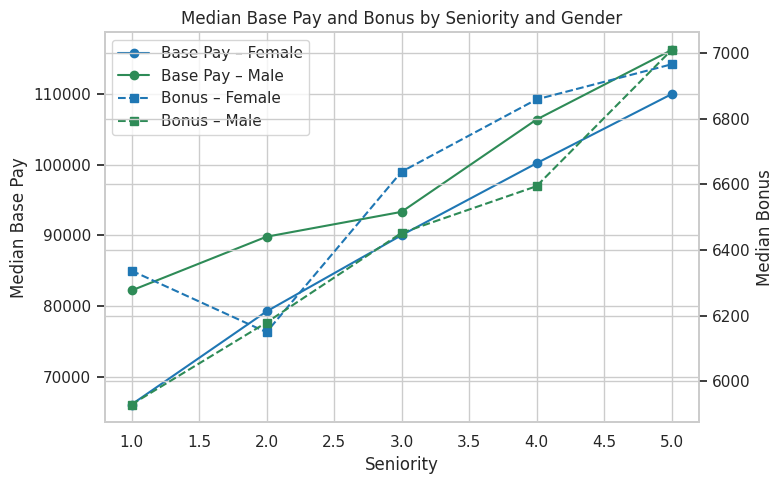

In [26]:
#Aggregate the data by seniority level and gender
seniority_comp = (
    df
    .groupby(['Seniority', 'Gender'])
    .agg(
        median_basepay=('BasePay', 'median'),
        median_bonus=('Bonus', 'median')
    )
    .reset_index()
)

#Split the aggregated dataset by gender for clearer plotting
female = seniority_comp[seniority_comp['Gender'] == 'Female']
male = seniority_comp[seniority_comp['Gender'] == 'Male']

#Create the main figure and the first axis (left Y-axis)
fig, ax1 = plt.subplots(figsize=(8, 5))

#Plot median Base Pay on the left Y-axis
ax1.plot(
    female['Seniority'],
    female['median_basepay'],
    marker='o',
    color='#1f77b4',  
    label='Base Pay – Female'
)
ax1.plot(
    male['Seniority'],
    male['median_basepay'],
    marker='o',
    color='#2E8B57', 
    label='Base Pay – Male'
)

#Label the left Y-axis and the X-axis
ax1.set_ylabel('Median Base Pay')
ax1.set_xlabel('Seniority')
ax1.tick_params(axis='y')

#Create a second Y-axis sharing the same X-axis (for Bonus)
ax2 = ax1.twinx()

#Plot median Bonus on the right Y-axis using dashed lines
ax2.plot(
    female['Seniority'],
    female['median_bonus'],
    linestyle='--',
    marker='s',
    color= '#1f77b4', 
    label='Bonus – Female'
)
ax2.plot(
    male['Seniority'],
    male['median_bonus'],
    linestyle='--',
    marker='s',
    color= '#2E8B57',  
    label='Bonus – Male'
)

#Label the right Y-axis
ax2.set_ylabel('Median Bonus')
ax2.tick_params(axis='y')

#Combine legends from both axes into a single legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper left'
)

#Add a descriptive title and adjust layout
plt.title('Median Base Pay and Bonus by Seniority and Gender')
plt.tight_layout()
plt.show()


Median base pay increases steadily with seniority for both genders, highlighting the strong role of experience in fixed compensation growth. A persistent gender gap in base pay is observed across seniority levels, indicating structural differences that are not confined to early career stages. In contrast, median bonus amounts remain relatively stable across seniority and display smaller, less consistent gender differences. This divergence suggests that base pay and bonus follow distinct compensation-setting mechanisms.

## 1.9-Summary - Notebook 1

| Factor / Analysis             | Main Finding                                                                                 | Gender Effect                                   | Notes / Insights                                                                 |
|-------------------------------|----------------------------------------------------------------------------------------------|------------------------------------------------|---------------------------------------------------------------------------------|
| Department Distribution       | Gender largely balanced across departments                                                 | N/A                                            | Some role-level imbalances may exist                                             |
| JobTitle (BasePay)            | Strong driver of BasePay differences                                                        | Males generally earn more in technical/managerial roles; females sometimes higher in Marketing Associate | Occupational segregation evident                                                 |
| Education (BasePay)           | Higher degrees → higher BasePay                                                             | N/A                                            | Education is a strong but not sole predictor of BasePay                          |
| Seniority (BasePay)           | BasePay increases steadily with seniority                                                  | Gender gaps persist across all levels          | Experience can sometimes outweigh education                                      |
| Age (BasePay)                 | Positive correlation with BasePay                                                          | N/A                                            | Older employees tend to earn more                                               |
| Bonus (Performance-driven)    | Strongly positively correlated with Performance Evaluation, negatively with Age           | Less consistent gender patterns                | Bonus mechanisms largely distinct from BasePay                                   |
| BasePay vs Bonus Relationship | Largely independent                                                                        | N/A                                            | Compensation mechanisms differ; one does not predict the other                  |
| Distributions                 | Right-skewed with notable outliers                                                        | N/A                                            | Median-based metrics preferred for interpretation                                 |
| Contextual / Weak Factors     | Department, certain performance levels                                                     | N/A                                            | Effects appear weaker or context-specific                                        |
| Key Structural Insight        | JobTitle, Education, Seniority, and Age are main drivers of BasePay differences            | Gender differences partially explained by role/experience | Clear patterns emerge but adjustment for multiple factors needed in next steps  |
